In [1]:
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

In [2]:
def read_data(model_name, explainer_name, dataset_name="imagenet-butterfly"):
    
    df = pd.read_csv(f"../../artifacts/2024-09-s40/experiments/pixel-flpping/{dataset_name}/{model_name}/{explainer_name}.csv")
    
    df = df.groupby(by="num_flipped_pixels").agg(dict(
        logit=["mean", "sem", "count"]
    ))
    return df

_df = read_data("imagenet-mobilenetl-tv", "mobilenetlrp0.0")

In [3]:
_df.index

Index([    0,   256,   512,   768,  1024,  1280,  1536,  1792,  2048,  2304,
       ...
       47872, 48128, 48384, 48640, 48896, 49152, 49408, 49664, 49920, 50176],
      dtype='int64', name='num_flipped_pixels', length=197)

In [4]:
mpl.cm.Blues(1)

(0.9655517108804306, 0.9823452518262207, 0.9990157631680123, 1.0)

In [5]:
arr_gammas = [0.0, 0.001, 0.01, 0.1, 1.0, 10]

In [6]:
color_space = np.linspace(0.3, 1.0, num=len(arr_gammas))
color_space

array([0.3 , 0.44, 0.58, 0.72, 0.86, 1.  ])

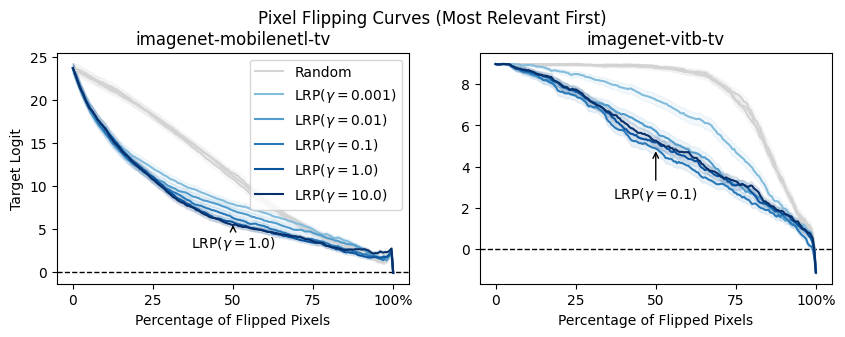

In [33]:
def color(name):
    if "random" in name:
        return "lightgray"
    elif "lrp" in name:
        gamma = float(name.replace("lrp", ""))
        ix = arr_gammas.index(gamma)
        return mpl.cm.Blues(color_space[ix])
    else:
        return None
def alias(name):
    if "random1" == name:
        return "Random"
    elif 'lrp' in name:
        gamma = name.replace("lrp", "")
        return f"LRP($\\gamma={gamma}$)"
    else:
        return None
def viz_curve(arr_model_names, arr_explainer_names, highlight):
    ncols = len(arr_model_names)
    plt.figure(figsize=(5*ncols, 3))
    plt.suptitle("Pixel Flipping Curves (Most Relevant First)", y=1.025)
    
    for mix, model_name in enumerate(arr_model_names):
        plt.subplot(1, ncols, mix+1)
        plt.title(model_name)
        plt.axhline(0, lw=1, ls="--", color="black")

        for explainer_name in arr_explainer_names:

            if "mobilenet" in model_name and "lrp" in explainer_name:
                actual_explainer_name = f"mobilenet{explainer_name}"
            else:
                actual_explainer_name = explainer_name

            df = read_data(model_name, actual_explainer_name)
            xticks = _df.index
            xticks = xticks / xticks[-1]
            mean = df["logit"]["mean"].values
            sem = df["logit"]["sem"].values
            plt.plot(
                xticks, 
                mean, 
                label=alias(explainer_name),
                color=color(explainer_name)
            )
            plt.fill_between(
                xticks,
                mean - sem,
                mean + sem,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
            if explainer_name == highlight[model_name]:
                v = mean[len(mean)//2]
                plt.annotate(
                    alias(explainer_name), 
                    (0.5, v),
                    (0.5, v / 2),
                    size=10,
                    ha="center",
                    arrowprops=dict(arrowstyle="->", facecolor='black'),
                )
        plt.xlabel("Percentage of Flipped Pixels")
        plt.xticks([0., 0.25, 0.5, 0.75, 1], ["0", "25", "50", "75", "100%"])
        if mix == 0:
            plt.ylabel("Target Logit")
            plt.legend()
    
        
viz_curve(
    arr_model_names=[
        "imagenet-mobilenetl-tv",
        "imagenet-vitb-tv",
    ],
    arr_explainer_names=[
        "random1",
        "random2",
        "random3",
        
#         "lrp0.0",
        "lrp0.001",
        "lrp0.01",
        
        "lrp0.1",
        "lrp1.0",
        "lrp10.0",
    ],
    highlight={
        "imagenet-mobilenetl-tv": "lrp1.0",
        "imagenet-vitb-tv": "lrp0.1",
    }
)

# Vis Accuracy Curve

In [11]:
import json

def load_accuracy_curve(model_name, layer, basis_name):
    with open(f"../../artifacts/2024-09-s40/experiments/accuracy-curves/imagenet-butterfly/{model_name}/{layer}/{basis_name}--uncentered/accuracy.json", "r") as fh:
        data = json.load(fh)
    return data

load_accuracy_curve(
    "imagenet-mobilenetl-tv",
    "features.12",
    "pca"
)

{'accuracies': [0.2633333206176758,
  0.1733333319425583,
  0.3233333230018616,
  0.36666667461395264,
  0.5333333611488342,
  0.6333333253860474,
  0.7400000095367432,
  0.7933333516120911,
  0.8133333325386047,
  0.8166666626930237,
  0.8333333134651184,
  0.8799999952316284,
  0.903333306312561,
  0.9100000262260437,
  0.9200000166893005,
  0.9399999976158142,
  0.95333331823349,
  0.95333331823349,
  0.9599999785423279,
  0.9666666388511658,
  0.9633333086967468,
  0.9599999785423279,
  0.9566666483879089,
  0.9566666483879089,
  0.9566666483879089,
  0.9700000286102295,
  0.9633333086967468,
  0.9599999785423279,
  0.9666666388511658,
  0.9599999785423279],
 'arr_ks': [1,
  2,
  4,
  6,
  8,
  10,
  12,
  14,
  16,
  18,
  20,
  22,
  24,
  26,
  28,
  30,
  32,
  34,
  36,
  38,
  40,
  42,
  44,
  46,
  48,
  50,
  52,
  54,
  56,
  112],
 'dims': 112,
 'losses': [1.7975703477859497,
  1.8512998819351196,
  1.6599667072296143,
  1.6800209283828735,
  1.3191920518875122,
  1.0274

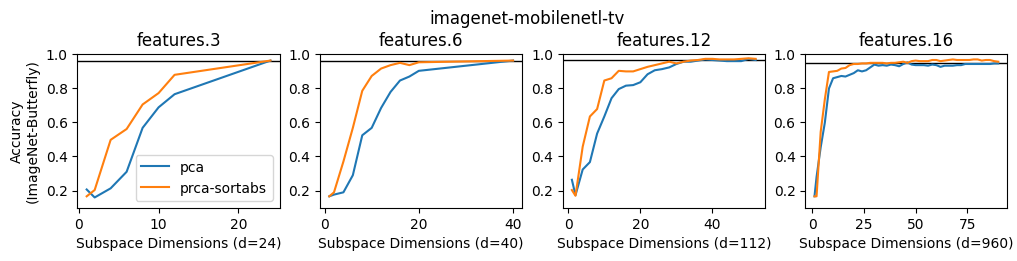

In [35]:
def show_accuracy(model_name, arr_layers):
    
    ncols = len(arr_layers)
    
    plt.figure(figsize=(3*ncols, 2))
    plt.suptitle(model_name, y=1.1)
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.1, 1])
        plt.title(layer)
        for bix, basis_name in enumerate(["pca", "prca-sortabs"]):
            data = load_accuracy_curve(
                model_name,
                layer,
                basis_name
            )
            arr_ks = np.array(data["arr_ks"] )
            arr_accs = np.array(data["accuracies"])
            
            d = arr_ks[-1]
            
            factor = d / 100
            if factor > 1:
                selected = arr_ks <= d/(factor+1)
                arr_ks = arr_ks[selected]
                arr_accs = arr_accs[selected]
                
            
            
            if bix == 0:
                plt.axhline(arr_accs[-1], ls="-", color="k", lw=1)
            plt.plot(
                arr_ks,
                arr_accs,
                label=basis_name
            )
            
        plt.xlabel(f"Subspace Dimensions (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy\n(ImageNet-Butterfly)")
            plt.legend()
show_accuracy(
    "imagenet-mobilenetl-tv",
    [
        "features.3",
        "features.6",
        "features.12",
        "features.16",
    ]
)

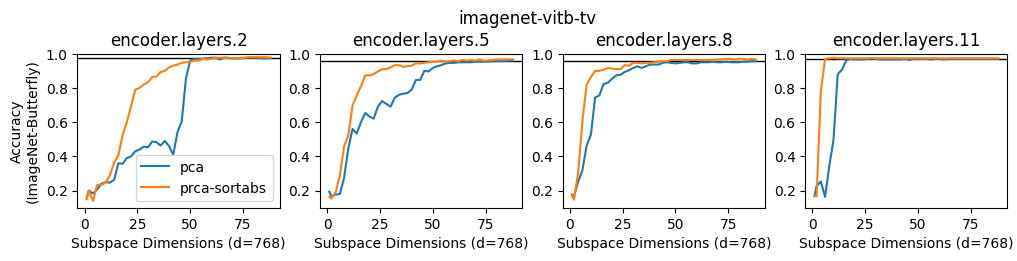

In [36]:
show_accuracy(
    "imagenet-vitb-tv",
    [
        "encoder.layers.2",
        "encoder.layers.5",
        "encoder.layers.8",
        "encoder.layers.11",
    ]
)

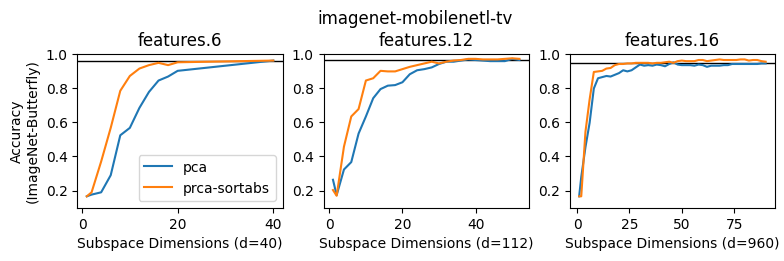

In [37]:
show_accuracy(
    "imagenet-mobilenetl-tv",
    [
#         "features.3",
        "features.6",
        "features.12",
        "features.16",
    ]
)

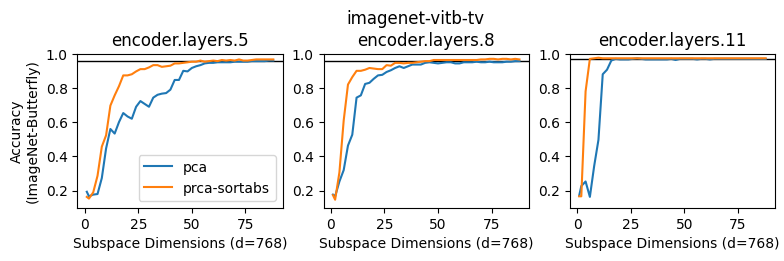

In [38]:
show_accuracy(
    "imagenet-vitb-tv",
    [
#         "encoder.layers.2",
        "encoder.layers.5",
        "encoder.layers.8",
        "encoder.layers.11",
    ]
)